In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow Version: ", tf.__version__)


TensorFlow Version:  2.15.0


In [2]:
model = models.Sequential()

# Add explicit Input layer to prevent Keras warnings
model.add(layers.Input(shape=(224, 224, 3)))

# Block 1
model.add(layers.Conv2D(32, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2
model.add(layers.Conv2D(64, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3
model.add(layers.Conv2D(128, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))

print("CNN feature extractor completed")



CNN feature extractor completed


In [3]:
# Flatten feature maps
model.add(layers.Flatten())

# Fully connected layer
model.add(layers.Dense(128, activation="relu"))

# Dropout to reduce overfitting
model.add(layers.Dropout(0.5))

# Output layer for 3 classes
model.add(layers.Dense(3, activation="softmax"))

print("CNN classification head completed")

CNN classification head completed


In [4]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")
model.summary()


Model compiled successfully
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin

In [5]:
# 1. Define the missing EarlyStopping callback!
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# 2. Generate dummy data for baseline testing
X_train = np.random.rand(30, 224, 224, 3)
y_train = tf.keras.utils.to_categorical(np.random.randint(0, 3, 30), 3)

print("Data shape:", X_train.shape)
print("Labels shape:", y_train.shape)

Data shape: (30, 224, 224, 3)
Labels shape: (30, 3)


In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5


1/1 [==============================] - 2s 2s/step - loss: 1.0977 - accuracy: 0.4167 - val_loss: 17.0018 - val_accuracy: 0.3333
Epoch 2/5
1/1 [==============================] - 1s 540ms/step - loss: 8.0766 - accuracy: 0.5000 - val_loss: 7.6384 - val_accuracy: 0.3333
Epoch 3/5
1/1 [==============================] - 0s 489ms/step - loss: 3.8002 - accuracy: 0.4583 - val_loss: 3.5203 - val_accuracy: 0.3333
Epoch 4/5
1/1 [==============================] - 1s 502ms/step - loss: 1.5180 - accuracy: 0.5000 - val_loss: 1.7559 - val_accuracy: 0.3333
Epoch 5/5
1/1 [==============================] - 0s 497ms/step - loss: 1.2074 - accuracy: 0.4167 - val_loss: 1.1966 - val_accuracy: 0.3333


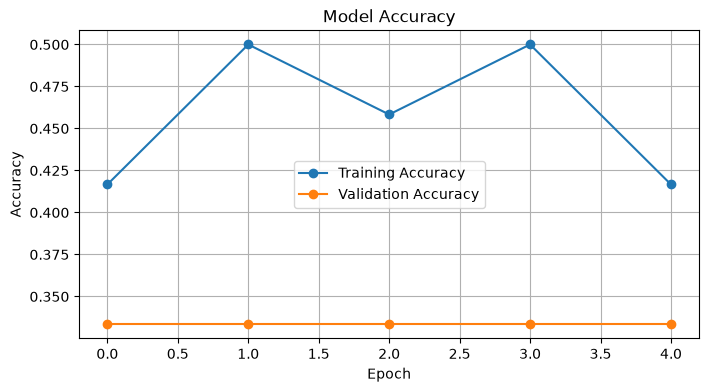

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy", marker="o")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", marker="o")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

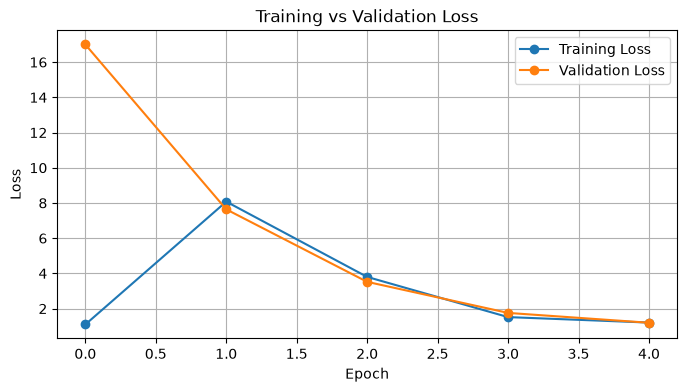

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss", marker="o")
plt.plot(history.history["val_loss"], label="Validation Loss", marker="o")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
print("Final Training Accuracy   :", round(history.history["accuracy"][-1] * 100, 2), "%")
print("Final Validation Accuracy :", round(history.history["val_accuracy"][-1] * 100, 2), "%")

Final Training Accuracy   : 41.67 %
Final Validation Accuracy : 33.33 %


In [10]:
# Ensure the models directory exists before saving
os.makedirs("../models", exist_ok=True)

model_path = "../models/baseline_cnn.keras"
model.save(model_path)

print(f"Baseline CNN model saved successfully to: {model_path}")

Baseline CNN model saved successfully to: ../models/baseline_cnn.keras


In [11]:
from tensorflow.keras.models import load_model

# Load using the exact same path where it was saved
loaded_model = load_model("../models/baseline_cnn.keras")

print("Model loaded successfully from disk.")
loaded_model.summary()

Model loaded successfully from disk.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (M

In [12]:
print("=" * 50)
print("Baseline CNN Project Completed Successfully")
print("=" * 50)

print("TensorFlow Version :", tf.__version__)
print("Optimizer          : Adam")
print("Loss Function      : Categorical Crossentropy")
print("Activation         : ReLU")
print("Output Activation  : Softmax")

print("\nModel is saved and ready for integration with src/predict.py and app.py!")

Baseline CNN Project Completed Successfully
TensorFlow Version : 2.15.0
Optimizer          : Adam
Loss Function      : Categorical Crossentropy
Activation         : ReLU
Output Activation  : Softmax

Model is saved and ready for integration with src/predict.py and app.py!
